In [31]:
import heeps
from heeps.util.img_processing import crop_img
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os.path
from astropy.visualization import imshow_norm,\
    SqrtStretch, MinMaxInterval, PercentileInterval, ManualInterval,\
    LinearStretch, AsinhStretch, SinhStretch, LogStretch

In [32]:
conf = dict(
    dir_current = '$HOME/workspace/heeps_metis/',
    dir_output = 'output_files',
    band = 'L',
    apo_drift = 0.02, # (% ptv)
    f_amp = 'wavefront/cbw/20221006/talbot/LM_rep_6_-0h30.fits',
    # f_amp = 'wavefront/cbw/20260127/talbot/L_rep_1.fits',
    avg = True,
    hfov = 1.5,
    ngrid = 2048,
    cpu_count=5
)

In [33]:
def get_psfs(conf, outdir='', case='scao_only',
             modes=['CVC', 'RAVC', 'APPIMG', 'APPLMS', 'CLC', 'SPP'],
             savefits=False, verbose=True, ndet=96):
    """
    Compute and display on-axis PSFs for ELT and selected coronagraphic modes.

    The function:
    - updates the input configuration with output path, phase cube, and ELT mode,
    - computes an ELT reference PSF,
    - loops over requested `modes` and applies mode-specific configuration updates,
    - propagates wavefronts (including APP positive/negative averaging),
    - displays cropped PSFs with a logarithmic stretch,
    - optionally writes FITS files for ELT and per-mode PSFs.

    Parameters
    ----------
    conf : dict
        HEEPS configuration dictionary. It is modified in place during execution.
    outdir : str, optional
        Subdirectory appended to `conf['dir_output']` for outputs.
    case : str, optional
        Tag used to build the input phase-cube filename
        (e.g. ``cube_Cfull_..._{case}_L_285.fits``).
        Only relevant if conf['add_phase'] is True.
    modes : list[str], optional
        List of observing/coronagraphic modes to evaluate.
        Full list is ``['CVC', 'CLC', 'RAVC', 'APPIMG', 'APPLMS']``.
    savefits : bool, optional
        If True, save computed PSFs as FITS files in the output directory.
    verbose : bool, optional
        If True, enable verbose output in configuration updates/propagation.
    ndet : int, optional
        Crop size (pixels) used for PSF display (overridden for APP modes).

    Returns
    -------
    None
        PSFs are displayed and optionally written to disk; no value is returned.

    Notes
    -----
    - APP modes compute two on-axis realizations (regular and `neg`) and average them.
    - VC modes print the leakage ratio: ``sum(psf_ON) / sum(psf_OFF)``.
    """
    conf.update(
        dir_output = os.path.join(conf['dir_output'], outdir),
        mode = 'ELT',
        # f_phase = 'wavefront/cfull/cube_Cfull_20220512_3600s_300ms_0piston_meters_%s'%case + '_L_285.fits',
    )
    conf = heeps.config.read_config(**conf)
    conf = heeps.config.update_config(**conf)
    wf = heeps.pupil.pupil(**conf, savefits=savefits)
    psf = heeps.wavefront.propagate(wf, **conf)
    #elt_peak = np.max(psf)
    #print('ELT peak = %.4f'%elt_peak)
    #psf /= elt_peak
    if savefits:
        fits.writeto(conf['dir_output'] + 'onaxis_PSF_%s_ELT.fits'%conf['band'], psf, overwrite=True)
    
    for conf['mode'] in modes:
        fig_title = conf['band'] + '-band ' + conf['mode']
        if 'RAVC' in conf['mode']:
            conf['mode'] = 'RAVC'
            conf['select_lyot']='auto'
            conf['f_lyot_stop']=''
        elif 'CVC' in conf['mode']:
            conf['mode'] = 'CVC'
            conf['select_lyot']='auto'
            conf['f_lyot_stop']=''
        elif 'CLC' in conf['mode']:
            conf['mode'] = 'CLC'
            conf['select_lyot']='auto'
            conf['f_lyot_stop']=''
        elif 'SPP' in conf['mode']:
            conf['mode'] = 'SPP'
            conf.update(f_spp_amp='optics/spp/SP_AP2_masked_rot_bin.fits') 
        elif 'APPIMG' in conf['mode']:
            conf['mode'] = 'APP'
            conf.update(f_app_amp='optics/app/METIS_IMG_aper_rot.fits',
                        f_app_phase='optics/app/METIS_IMG_gvAPP_final_rot.fits')
        elif 'APPLMS' in conf['mode']:
            conf['mode'] = 'APP'
            conf.update(f_app_amp='optics/app/METIS_LMS_aper.fits',
                        f_app_phase='optics/app/METIS_LMS_gvAPP_final.fits')
        conf = heeps.config.read_config(**conf)
        conf = heeps.config.update_config(**conf, verbose=verbose)
        wf = heeps.pupil.pupil(**conf)
        ndet_crop = np.copy(ndet)
        mstretch=LogStretch()
        if 'VC' in conf['mode']:
            psf_OFF = heeps.wavefront.propagate(wf, onaxis=False, **conf)
            psf_ON = heeps.wavefront.propagate(wf, onaxis=True, **conf)
            print('mode = %s, leakage = %.2e'%(conf['mode'], np.sum(psf_ON)/np.sum(psf_OFF)))
        elif 'APP' in conf['mode']:
            psf_ON = heeps.wavefront.propagate(wf, onaxis=True,  verbose=verbose, **conf)
            #plt.figure();plt.imshow(crop_img(np.log(psf_ON), conf['ndet'])); plt.colorbar()
            conf['mode'] += 'neg'
            psf_ON_neg = heeps.wavefront.propagate(wf, onaxis=True, verbose=False, **conf)
            #plt.figure();plt.imshow(crop_img(np.log(psf_ON_neg), conf['ndet'])); plt.colorbar()
            psf_ON += psf_ON_neg
            psf_ON /= 2
            ndet_crop = np.copy(conf['ndet'])
            mstretch = LogStretch(a=1e6) # enhancing small value wrt to default LogStretch
        else:
            psf_ON = heeps.wavefront.propagate(wf, onaxis=True, **conf)
            if 'SPP' in conf['mode']: 
                mstretch = LogStretch(a=1e6) # enhancing small value wrt to default LogStretch

        
        plt.figure()
        im, _ = imshow_norm(crop_img(psf_ON, int(ndet_crop)), stretch=mstretch)
        plt.colorbar(im)
        plt.title(fig_title)
        

        #psf_ON /= elt_peak
        if savefits:
            fits.writeto(conf['dir_output'] + 'onaxis_PSF_%s_%s.fits'%(conf['band'],conf['mode']), psf_ON, overwrite=True)

### ideal


   Auto-selection Lyot stop from definition


   2026-04-10 16:17:05, e2e simulation using 5 cores
   2026-04-10 16:17:05, completed in 0.67 seconds
Simulation config: band=L, mode=CVC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   loading vortex back-propagation params
   vc_charge=2, ngrid=2048, diam_norm=1.0838, beam_ratio=0.2572
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition


   2026-04-10 16:17:06, e2e simulation using 5 cores
   2026-04-10 16:17:07, completed in 0.93 seconds
   2026-04-10 16:17:07, e2e simulation using 5 cores
   2026-04-10 16:17:09, completed in 2.19 seconds
mode = CVC, leakage = 3.10e-02
Simulation config: band=L, mode=RAVC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   ravc_calc=False, ravc_t=0.7909, ravc_r=0.5190
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from defini

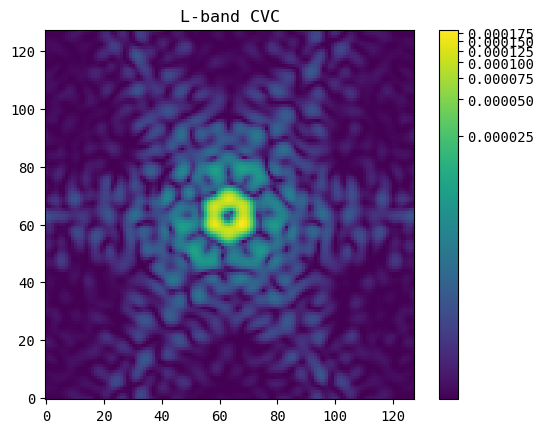

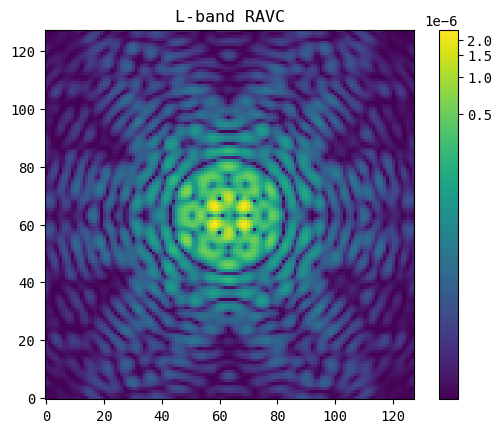

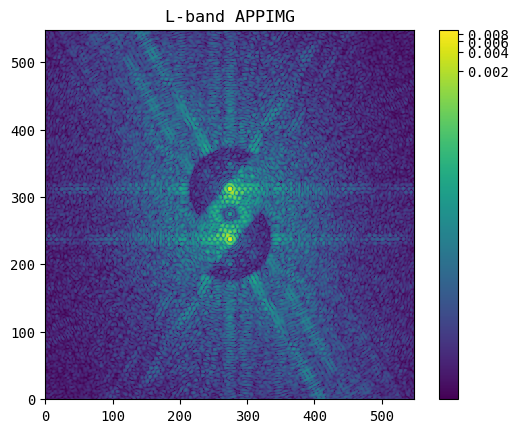

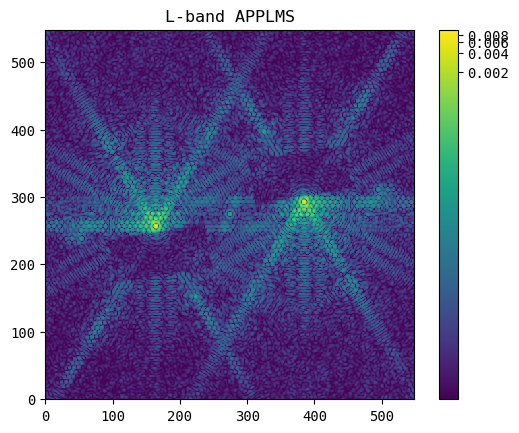

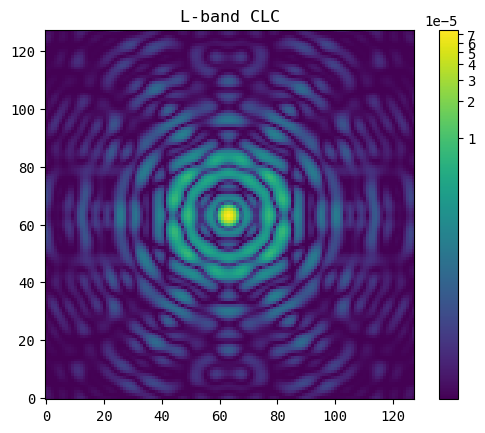

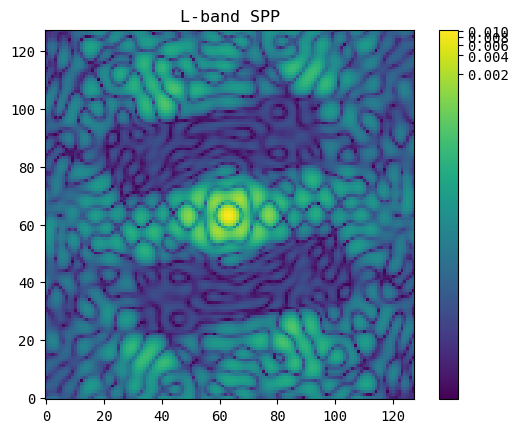

In [27]:
conf.update(
    nframes_avg = 1,
    nframes=1,
    # f_pupil = 'pupil/ELT_fullM1_nov2024.fits',
    add_phase = False,
    add_apo_drift = False,
    add_amp = False,
    add_cl_vort = False,
    
)
get_psfs(conf, outdir='long_exp/ideal',
        #  modes=['CVC', 'RAVC', 'APPIMG'],
        # modes=['CLC', 'SPP', 'APPIMG', 'APPLMS'],
        ndet=128, savefits=True)

### scao only


   Auto-selection Lyot stop from definition




/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


   2026-04-10 16:20:00, e2e simulation using 5 cores
   2026-04-10 16:20:01, completed in 0.7 seconds
Simulation config: band=L, mode=CVC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   loading vortex back-propagation params
   vc_charge=2, ngrid=2048, diam_norm=1.0838, beam_ratio=0.2572
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition




/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


   2026-04-10 16:20:04, e2e simulation using 5 cores
   2026-04-10 16:20:05, completed in 0.88 seconds


...

   2026-04-10 16:20:34, e2e simulation using 5 cores
   2026-04-10 16:20:35, completed in 0.84 seconds
Simulation config: band=L, mode=CLC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition




/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


   2026-04-10 16:20:38, e2e simulation using 5 cores
   2026-04-10 16:20:40, completed in 1.96 seconds
Simulation config: band=L, mode=SPP
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition
   no auto-selected Lyot stop for mode=SPP




/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


   2026-04-10 16:20:43, e2e simulation using 5 cores
   2026-04-10 16:20:44, completed in 0.91 seconds


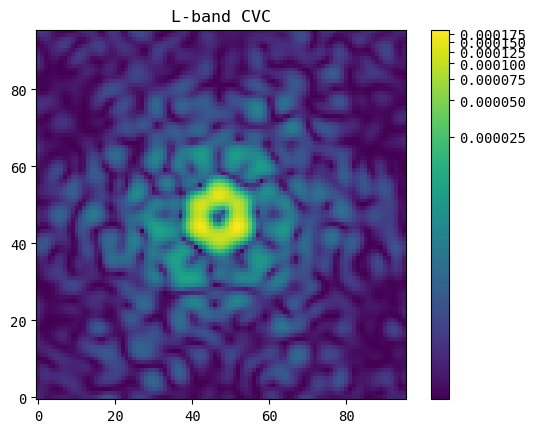

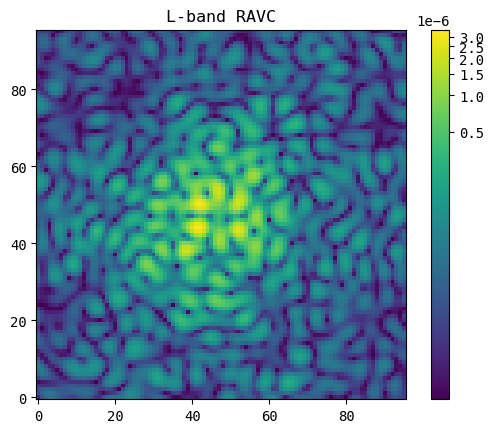

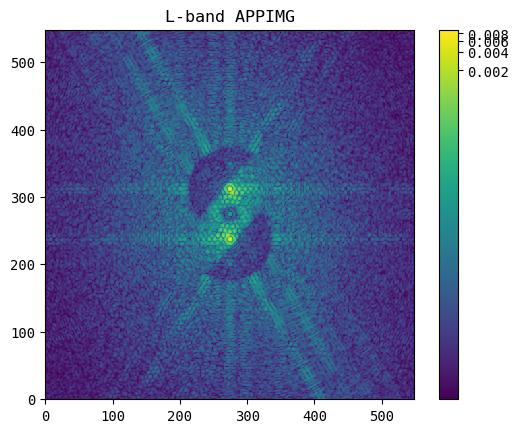

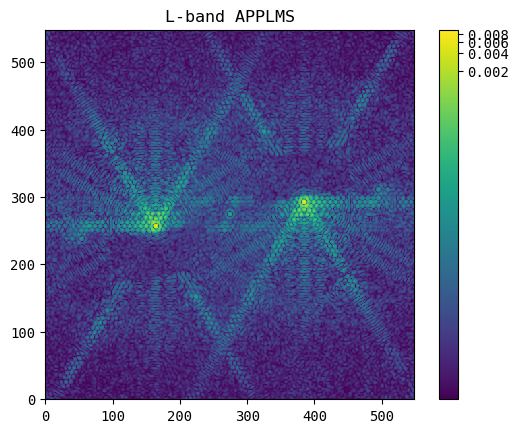

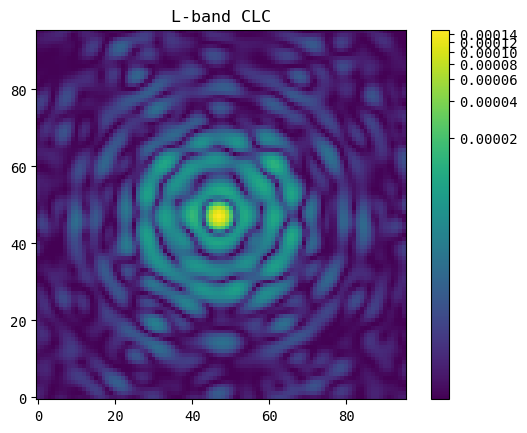

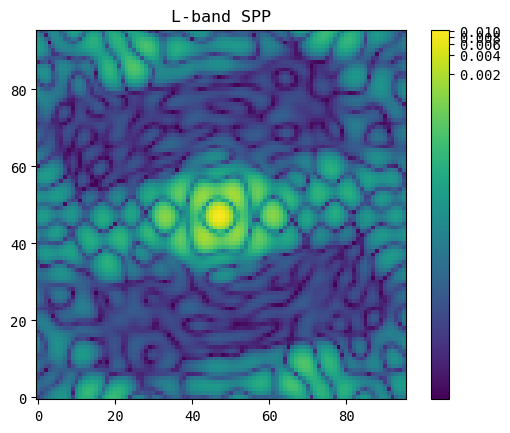

In [34]:
conf.update(
    nframes_avg = 1,
    add_phase = True,
    add_apo_drift = False,
    add_amp = False,
    add_cl_vort = False,
)
get_psfs(conf, outdir='long_exp/scao_only_1frame')

### long exposure


   Auto-selection Lyot stop from definition




/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/opt/homebrew/Caskroom/miniforge/base/envs/numpy_arm/lib/python3.12/site-packages/asdf/asdf.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources pack

   2026-04-10 16:21:19, e2e simulation using 5 cores
   2026-04-10 16:21:36, completed in 17.23 seconds
Simulation config: band=L, mode=CVC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   loading vortex back-propagation params
   vc_charge=2, ngrid=2048, diam_norm=1.0838, beam_ratio=0.2572
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition


   2026-04-10 16:21:37, e2e simulation using 5 cores
   2026-04-10 16:21:57, completed in 19.71 seconds
   2026-04-10 16:21:57, e2e simulation using 5 cores
   2026-04-10 16:22:42, completed in 45.27 seconds
mode = CVC, leakage = 4.43e-02
Simulation config: band=L, mode=RAVC
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   ravc_calc=False, ravc_t=0.7909, ravc_r=0.5190
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

   Auto-selection Lyot stop from definition


   2026-04-10 16:22:43, e2e simulatio

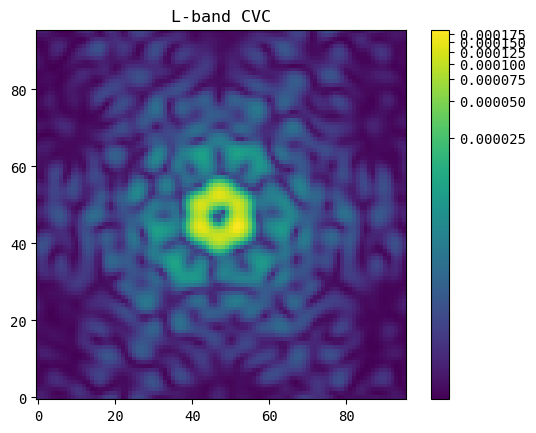

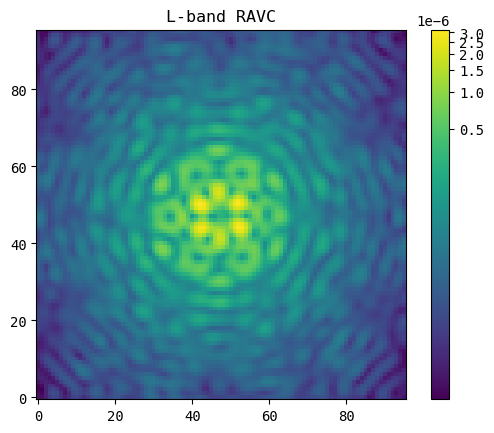

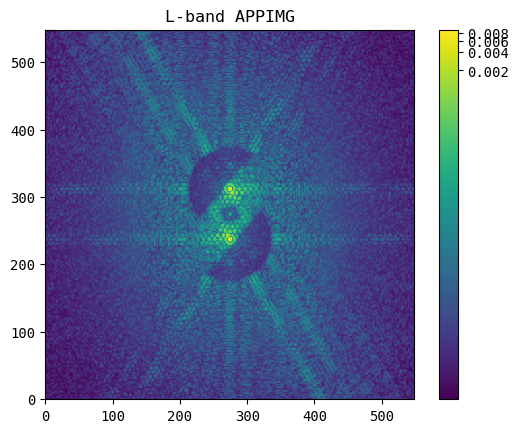

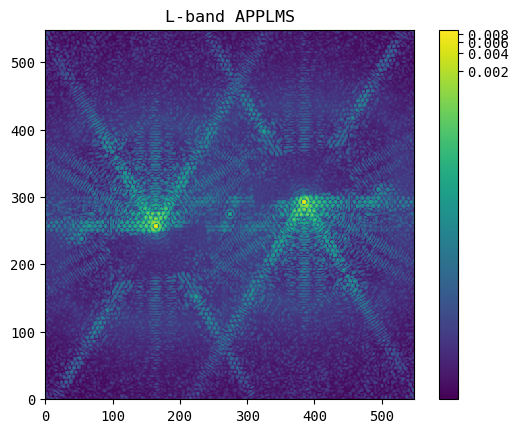

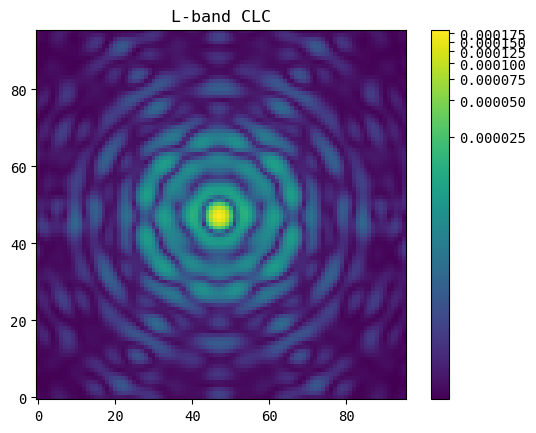

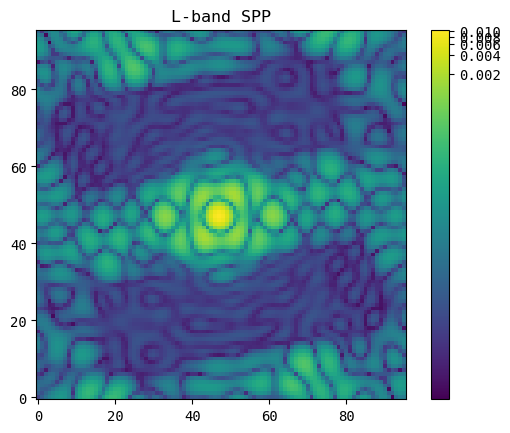

In [35]:
conf.update(
    nframes_avg = 100,
    add_phase = True,
    add_apo_drift = False,
    add_amp = False,
    add_cl_vort = False,
)
get_psfs(conf, outdir='long_exp/scao_only')

   2024-12-20 15:49:10, e2e simulation using 56 cores
   2024-12-20 15:49:39, completed in 28.56 seconds
Simulation config: band=L, mode=APPIMG
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

On-axis PSF:
‾‾‾‾‾‾‾‾‾‾‾‾
Load phase screens from 'cube_Cfull_20220512_3600s_300ms_0piston_meters_all_ncpa_L_285.fits'
   nscreens=100 (nframes=100, nstep=1)
Load amp screens from 'LM_rep_6_-0h30.fits'
   nscreens=100
Create on-axis PSF cube
   amplitude screen not preloaded: len(amp_screens)=100
   apply APP stop from 'METIS_IMG_aper_rot.fits'
   apply APP phase from 'METIS_IMG_gvAPP_final_rot.fits'
   2024-12-20 15:49:47, e2e simulation using 56 cores
   2024-12-20 15:50:15, completed in 27.84 seconds
Average PSF cube

   2024-12-20 15:50:25, e2e simulation using 56 cores
   2024-12-20 15:50:53, completed in 28.02 seconds
Simulation config: band=L, mode=APPLMS
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, p

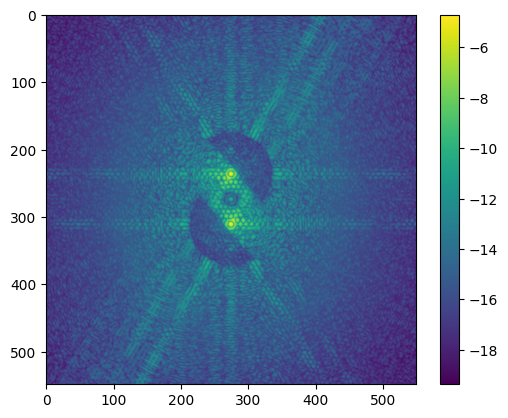

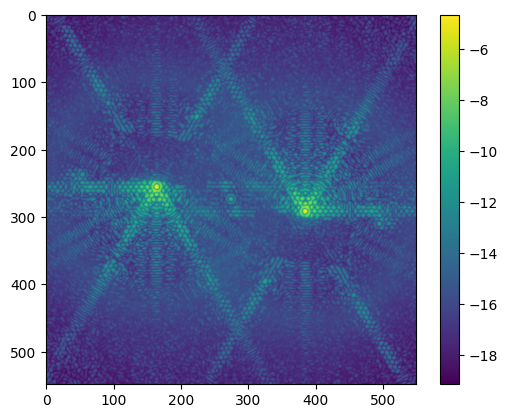

In [ ]:
conf.update(
    nframes_avg = 100,
    f_pupil = 'pupil/ELT_fullM1_nov2024_refl_0.10ptv.fits', # /!\ latest f_pupil is feb2025
    add_phase = True,
    add_apo_drift = True,
    add_amp = True,
    add_cl_vort = True,
)
get_psfs(conf, outdir='long_exp/all_effects', case='all_ncpa')#, modes=['RAVC'])

   2024-12-20 15:52:16, e2e simulation using 56 cores
   2024-12-20 15:52:42, completed in 26.7 seconds
Simulation config: band=L, mode=APPIMG
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, pscale=5.4700 mas, lam=3.8045E-06 m
   hfov=1.5 arcsec (-> 70.61 lam/D)
   detector size (ndet)=549 (141.23 lam/D)

On-axis PSF:
‾‾‾‾‾‾‾‾‾‾‾‾
Load phase screens from 'cube_Cfull_20220512_3600s_300ms_0piston_meters_all_ncpa_L_285.fits'
   nscreens=100 (nframes=100, nstep=1)
Load amp screens from 'LM_rep_6_-0h30.fits'
   nscreens=100
Create on-axis PSF cube
   amplitude screen not preloaded: len(amp_screens)=100
   apply APP stop from 'METIS_IMG_aper_rot.fits'
   apply APP phase from 'METIS_IMG_gvAPP_final_rot.fits'
   2024-12-20 15:52:52, e2e simulation using 56 cores
   2024-12-20 15:53:19, completed in 27.1 seconds
Average PSF cube

   2024-12-20 15:53:28, e2e simulation using 56 cores
   2024-12-20 15:53:55, completed in 26.93 seconds
Simulation config: band=L, mode=APPLMS
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
   npupil=571, psc

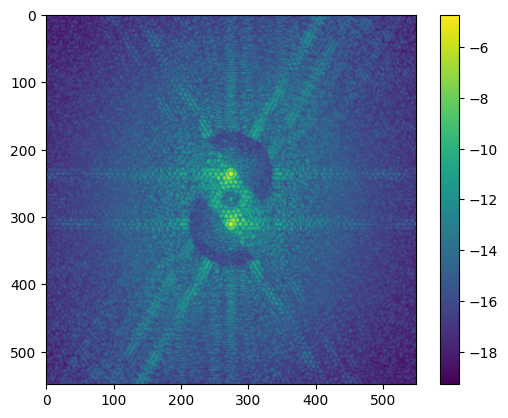

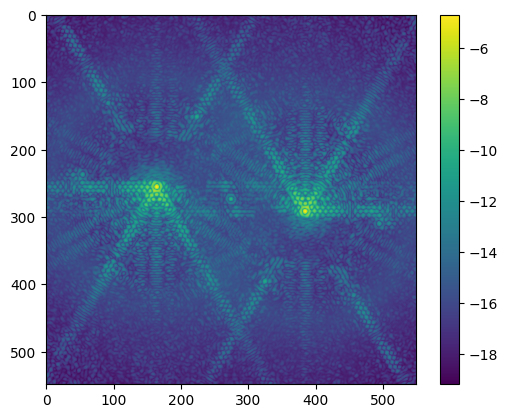

In [ ]:
conf.update(
    nframes_avg = 100,
    f_pupil = 'pupil/ELT_fullM1_nov2024_refl_0.10ptv_misseg_1x7.fits', # /!\ latest f_pupil is feb2025
    add_phase = True,
    add_apo_drift = True,
    add_amp = True,
    add_cl_vort = True,
)
get_psfs(conf, outdir='long_exp/all_effects_misseg', case='all_ncpa')#, modes=['RAVC'])